**You are the average of the five people you spend the most time with.    - Jim Rohn**

The Quote: Suggests that an individual is shaped by the influences of the people closest to them.

k-NN Algorithm: Determines the class or value of a data point based on the characteristics of its closest neighbors in the feature space.

In both cases, proximity to a group influences the outcome:

In the quote, proximity is in terms of relationships or time spent.

In k-NN, proximity is in terms of Euclidean distance (or another metric) in a feature space.

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix

In [54]:
# Load Data
df_original = pd.read_csv('Children Recode_final.csv')

# Drop unnecessary columns
df = df_original.drop(['Underweight', 'Wasting'], axis=1)

# Feature and Target selection
X = df.drop(columns=['Stunting'])
y = df['Stunting']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# KNN Model
knn = KNeighborsClassifier(n_neighbors=18)
knn.fit(X_train, y_train)

# Predictions & Accuracy
predictions = knn.predict(X_test)
accuracy = knn.score(X_test, y_test)

accuracy


0.7745535714285714

### K-value for the best performance

In [59]:
# Manual method
k_range = range(1, 31)
accuracy_scores = []

# Peform cross-validation for each k
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv = 18, scoring = 'accuracy') # 5 fold cross-validation
    accuracy_scores.append(scores.mean())

best_k = k_range[np.argmax(accuracy_scores)]
print(f"Best k value: {best_k}")

Best k value: 19


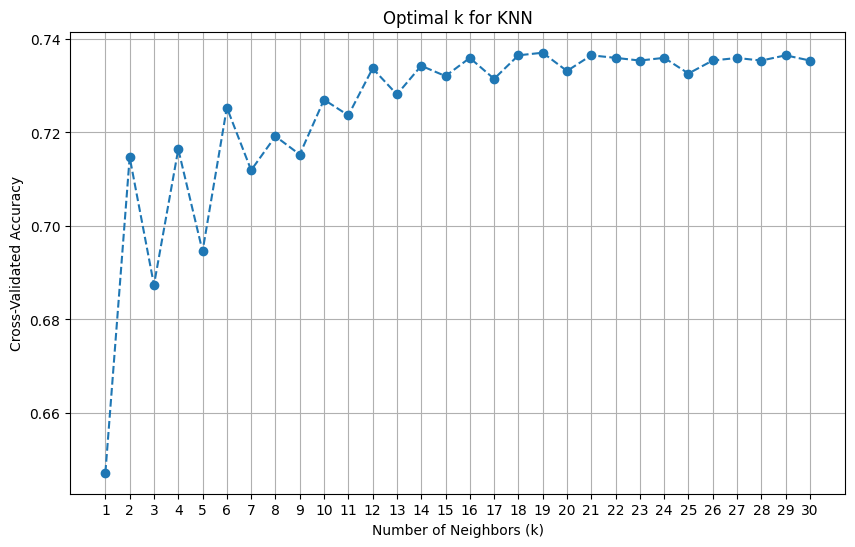

Best k: 19, Best Accuracy: 0.7370


In [60]:
# Plot k vs accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracy_scores, marker='o', linestyle='dashed')
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Optimal k for KNN')
plt.xticks(k_values)
plt.grid(True)
plt.show()

print(f'Best k: {best_k}, Best Accuracy: {best_accuracy:.4f}')


In [42]:
# StratifiedKFold because of class imbalance

from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import StratifiedKFold

# Compare k=19 vs k=27
best_k_values = [19, 27]

for k in best_k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    
    test_accuracy = accuracy_score(y_test, y_pred)
    print(f'k={k} | Test Accuracy: {test_accuracy:.4f}')
    print(classification_report(y_test, y_pred))
    print('-' * 50)

# Stratified K-Fold for better validation
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_results = {}

for k in best_k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_scores = cross_val_score(knn, X_train, y_train, cv=skf, scoring='accuracy')
    cv_results[k] = np.mean(cv_scores)

print(f'Cross-Validation Results: {cv_results}')


k=19 | Test Accuracy: 0.7746
              precision    recall  f1-score   support

           0       0.78      0.99      0.87       343
           1       0.70      0.07      0.12       105

    accuracy                           0.77       448
   macro avg       0.74      0.53      0.50       448
weighted avg       0.76      0.77      0.70       448

--------------------------------------------------
k=27 | Test Accuracy: 0.7701
              precision    recall  f1-score   support

           0       0.77      0.99      0.87       343
           1       0.62      0.05      0.09       105

    accuracy                           0.77       448
   macro avg       0.70      0.52      0.48       448
weighted avg       0.74      0.77      0.69       448

--------------------------------------------------
Cross-Validation Results: {19: np.float64(0.7314369956548729), 27: np.float64(0.7342271880819368)}


In [62]:
# Using GridSearchCV
knn = KNeighborsClassifier()

# Define the grid of k values
param_grid = {'n_neighbors': range(1, 31)}

# Perform grid search with cross-validation
grid_search = GridSearchCV(knn, param_grid, cv=10, scoring='accuracy')
grid_search.fit(X_train, y_train)

# Best k value
print("Best k:", grid_search.best_params_['n_neighbors'])
print("Best accuracy:", grid_search.best_score_)


Best k: 18
Best accuracy: 0.7359031657355681


Even thoufh best k value received is 11, the default k = 5 works better for accuracy.

In [9]:
# Synthetic Minority Oversampling Technique (SMOTE)

y.value_counts()

Stunting
0    1660
1     579
Name: count, dtype: int64

1. why do the k=11 has less accuracy
2. 